In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

tf.config.set_visible_devices([], 'GPU')
tf.config.threading.set_inter_op_parallelism_threads(0)
tf.config.threading.set_intra_op_parallelism_threads(0)

print('TF version :', tf.__version__)
print('Running on : CPU')

TF version : 2.20.0
Running on : CPU


In [2]:
import os, sys

# ── Robust path fix — works regardless of where notebook is opened from ──
notebook_dir = os.getcwd()
print("Notebook running from:", notebook_dir)

# Walk up until we find the VISIONEXTRACT root (has a 'src' folder)
root = notebook_dir
for _ in range(5):
    if os.path.isdir(os.path.join(root, 'src')):
        break
    root = os.path.dirname(root)

src_path = os.path.join(root, 'src')
print("src/ found at:", src_path)
print("Files in src/ :", os.listdir(src_path))

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from model_deeplab import build_deeplabv3plus, freeze_encoder, unfreeze_encoder
#from utils_deeplab import DeepLabTrainGenerator, DeepLabValGenerator, bce_dice_loss
from utils_deeplab import DeepLabTrainGenerator, DeepLabValGenerator, bce_dice_loss, BinaryIoU

# ── Data paths (built from root) ─────────────────────────────────────────────
TRAIN_DIR = os.path.join(root, 'data', 'processed', 'train')
VAL_DIR   = os.path.join(root, 'data', 'processed', 'val')
TEST_DIR  = os.path.join(root, 'data', 'processed', 'test')
MODEL_DIR = notebook_dir

IMG_SIZE     = (256, 256)
INPUT_SHAPE  = (256, 256, 3)
BATCH_SIZE   = 4

STAGE1_LR     = 1e-3
STAGE1_EPOCHS = 30
STAGE2_LR     = 1e-5
STAGE2_EPOCHS = 20

print('Train dir :', TRAIN_DIR)
print('Val   dir :', VAL_DIR)
print('Model dir :', MODEL_DIR)

Notebook running from: c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks
src/ found at: c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\src
Files in src/ : ['model.py', 'model1.py', 'model_deeplab.py', 'split_dataset.py', 'utils.py', 'utils1.py', 'utils2.py', 'utils3.py', 'utils_deeplab.py', '__pycache__']
Train dir : c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\processed\train
Val   dir : c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\processed\val
Model dir : c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks


[TrainGen] 3500 images found in c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\processed\train
[ValGen]   750 images found in c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\data\processed\val
Train batches : 875
Val   batches : 187

Batch X : (4, 256, 256, 3)  range [0.00, 1.00]
Batch y : (4, 256, 256, 1)  range [0.00, 1.00]


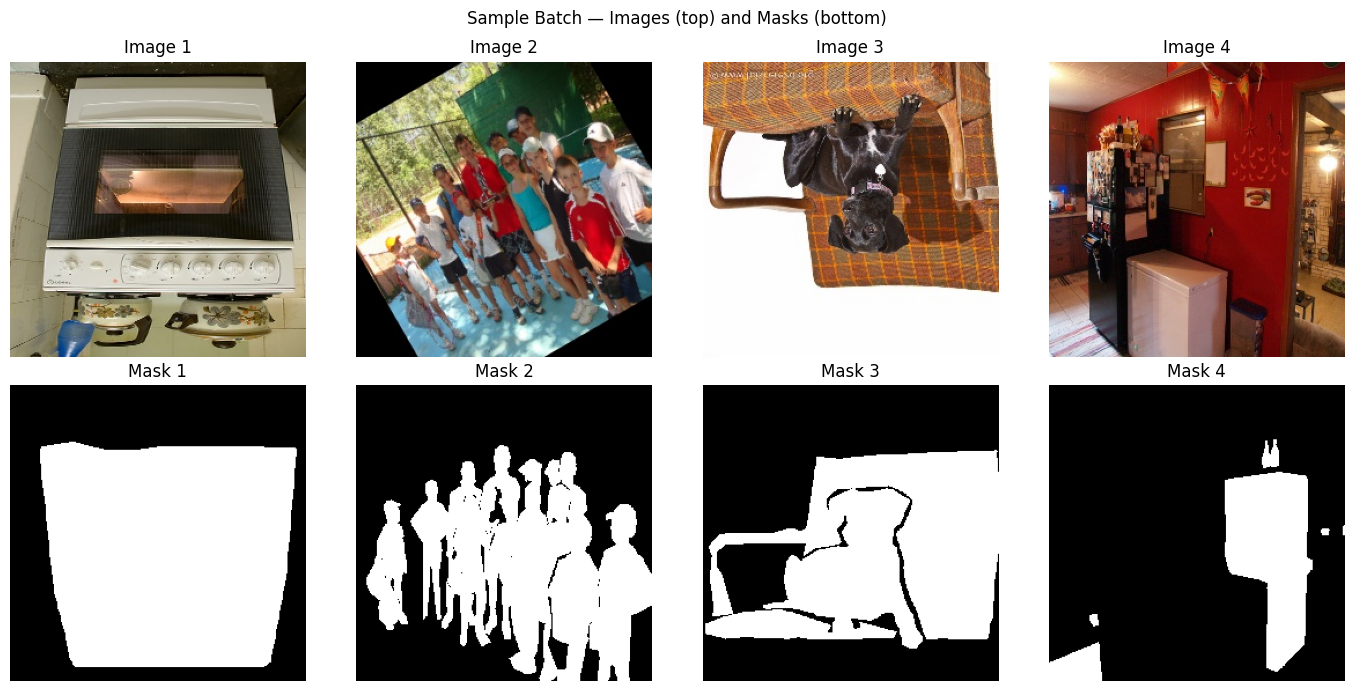

In [3]:
train_gen = DeepLabTrainGenerator(TRAIN_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE)
val_gen   = DeepLabValGenerator(VAL_DIR,     batch_size=BATCH_SIZE, img_size=IMG_SIZE)

print(f'Train batches : {len(train_gen)}')
print(f'Val   batches : {len(val_gen)}')

X_s, y_s = train_gen[0]
print(f'\nBatch X : {X_s.shape}  range [{X_s.min():.2f}, {X_s.max():.2f}]')
print(f'Batch y : {y_s.shape}  range [{y_s.min():.2f}, {y_s.max():.2f}]')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(X_s[i])
    axes[0, i].set_title(f'Image {i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(y_s[i, :, :, 0], cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}');  axes[1, i].axis('off')
plt.suptitle('Sample Batch — Images (top) and Masks (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
model, mobilenet_backbone = build_deeplabv3plus(
    input_shape=INPUT_SHAPE, num_classes=1
)

model.summary(line_length=100)
print(f'\nTotal params      : {model.count_params():,}')
print(f'MobileNetV2 params: {mobilenet_backbone.count_params():,}')

c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\src\model_deeplab.py:53: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = tf.keras.applications.MobileNetV2(


Model: "VisionExtract_DeepLabV3Plus_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1 (Conv2D)              │ (None, 128, 128, 32)    │            864 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_Conv1                    │ (None, 128, 128, 32)    │            128 │ Conv1[0][0]             │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1_relu (ReLU)           │ (None, 128, 128, 32)    │              0 │ bn_Conv1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise     │ (None, 128, 128, 32)    │            288 │ Conv1_relu[0][0]        │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_BN  │ (None, 128, 128, 32)    │            128 │ expanded_conv_depthwis… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_re… │ (None, 128, 128, 32)    │              0 │ expanded_conv_depthwis… │
│ (ReLU)                      │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project       │ (None, 128, 128, 16)    │            512 │ expanded_conv_depthwis… │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project_BN    │ (None, 128, 128, 16)    │             64 │ expanded_conv_project[… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand (Conv2D)     │ (None, 128, 128, 96)    │          1,536 │ expanded_conv_project_… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_BN           │ (None, 128, 128, 96)    │            384 │ block_1_expand[0][0]    │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_relu (ReLU)  │ (None, 128, 128, 96)    │              0 │ block_1_expand_BN[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_pad (ZeroPadding2D) │ (None, 129, 129, 96)    │              0 │ block_1_expand_relu[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise           │ (None, 64, 64, 96)      │            864 │ block_1_pad[0][0]       │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise_BN        │ (None, 64, 64, 96)      │    

 Total params: 3,177,025 (12.12 MB)

 Trainable params: 3,157,633 (12.05 MB)

 Non-trainable params: 19,392 (75.75 KB)


Total params      : 3,177,025
MobileNetV2 params: 2,257,984


In [5]:
print('=' * 60)
print('STAGE 1 — Decoder warm-up | Encoder FROZEN | LR = 1e-3')
print('=' * 60)

freeze_encoder(mobilenet_backbone)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE1_LR), 
    loss=bce_dice_loss,
    metrics=[
        BinaryIoU(threshold=0.5, name="binary_iou"),
        "accuracy"
    ]
)

stage1_callbacks = [
    # In stage1_callbacks AND stage2_callbacks, replace:
ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'deeplab_best_stage1.keras'),
    monitor='val_binary_iou',   # ← changed from val_mean_iou
    mode='max',
    save_best_only=True, verbose=1
),
EarlyStopping(
    monitor='val_binary_iou',   # ← changed
    mode='max',
    patience=7, restore_best_weights=True, verbose=1
),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    CSVLogger(os.path.join(MODEL_DIR, 'deeplab_log_stage1.csv'), append=False)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)

STAGE 1 — Decoder warm-up | Encoder FROZEN | LR = 1e-3
Encoder FROZEN — 154 layers frozen.
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7462 - binary_iou: 0.4216 - loss: 0.5142
Epoch 1: val_binary_iou improved from None to 0.50230, saving model to c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks\deeplab_best_stage1.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 479s 543ms/step - accuracy: 0.7618 - binary_iou: 0.4454 - loss: 0.4890 - val_accuracy: 0.8302 - val_binary_iou: 0.5023 - val_loss: 0.4025 - learning_rate: 0.0010
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.7770 - binary_iou: 0.4772 - loss: 0.4621
Epoch 2: val_binary_iou improved from 0.50230 to 0.55078, saving model to c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks\deeplab_best_stage1.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 477s 545ms/step - accuracy: 0.7790 - binary_iou: 0.4714 - loss: 0.4637 - val_accuracy: 0.8364 - val_binary_iou: 0.5508 - val_loss: 0.3794 - learning_rat

KeyboardInterrupt: 

In [5]:
# ── Resume Stage 1 from epoch 19 ─────────────────────────────────────────────

# Load the best weights saved so far
model.load_weights(os.path.join(MODEL_DIR, 'deeplab_best_stage1.keras'))
print("Loaded weights from deeplab_best_stage1.keras")

# Make sure encoder is still frozen
freeze_encoder(mobilenet_backbone)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss=bce_dice_loss,
    metrics=[
        BinaryIoU(threshold=0.5, name="binary_iou"),
        "accuracy"
    ]
)

# Resume from epoch 19, run remaining 11 epochs (19 done, 30 total)
REMAINING_EPOCHS = 30 - 19   # = 11

stage1_callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'deeplab_best_stage1.keras'),
        monitor='val_binary_iou', mode='max',
        save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_binary_iou', mode='max',
        patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    CSVLogger(
        os.path.join(MODEL_DIR, 'deeplab_log_stage1_resumed.csv'),
        append=False
    )
]

history1_resumed = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=REMAINING_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)

Loaded weights from deeplab_best_stage1.keras
Encoder FROZEN — 154 layers frozen.
Epoch 1/11
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.8234 - binary_iou: 0.5558 - loss: 0.3875
Epoch 1: val_binary_iou improved from None to 0.60757, saving model to c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks\deeplab_best_stage1.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 511s 579ms/step - accuracy: 0.8238 - binary_iou: 0.5548 - loss: 0.3862 - val_accuracy: 0.8412 - val_binary_iou: 0.6076 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 2/11
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8298 - binary_iou: 0.5661 - loss: 0.3742
Epoch 2: val_binary_iou did not improve from 0.60757
875/875 ━━━━━━━━━━━━━━━━━━━━ 527s 602ms/step - accuracy: 0.8283 - binary_iou: 0.5653 - loss: 0.3766 - val_accuracy: 0.8543 - val_binary_iou: 0.5925 - val_loss: 0.3415 - learning_rate: 0.0010
Epoch 3/11
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8287 - binary_iou: 0.5637 - loss: 0.373

In [24]:
model.load_weights(os.path.join(MODEL_DIR, 'deeplab_best_stage1.keras'))
print("Loaded Stage 1 weights")

unfreeze_encoder(mobilenet_backbone, from_block=10)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # back to safe LR
    loss=bce_dice_loss,
    metrics=[BinaryIoU(threshold=0.5, name="binary_iou"), "accuracy"]
)

stage2_callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'deeplab_best_stage2.keras'),
        monitor='val_binary_iou', mode='max',
        save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_binary_iou', mode='max',
        patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7, verbose=1
    ),
    CSVLogger(os.path.join(MODEL_DIR, 'deeplab_log_stage2.csv'), append=False)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=stage2_callbacks,
    verbose=1
)

model.load_weights(os.path.join(MODEL_DIR, 'deeplab_best_stage2.keras'))
print("Best Stage 2 weights loaded")

Loaded Stage 1 weights
Encoder partially UNFROZEN — 64 layers from block 10.
Epoch 1/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8284 - binary_iou: 0.5619 - loss: 0.3755
Epoch 1: val_binary_iou improved from None to 0.60098, saving model to c:\Users\Mula Sriya\OneDrive\Desktop\VISIONEXTRACT\notebooks\deeplab_best_stage2.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 544s 614ms/step - accuracy: 0.8283 - binary_iou: 0.5614 - loss: 0.3764 - val_accuracy: 0.8502 - val_binary_iou: 0.6010 - val_loss: 0.3401 - learning_rate: 1.0000e-05
Epoch 2/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8276 - binary_iou: 0.5609 - loss: 0.3766
Epoch 2: val_binary_iou did not improve from 0.60098
875/875 ━━━━━━━━━━━━━━━━━━━━ 544s 622ms/step - accuracy: 0.8273 - binary_iou: 0.5613 - loss: 0.3767 - val_accuracy: 0.8510 - val_binary_iou: 0.5988 - val_loss: 0.3391 - learning_rate: 1.0000e-05
Epoch 3/25
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.8357 - binary_iou: 0.5780 - loss: 0.

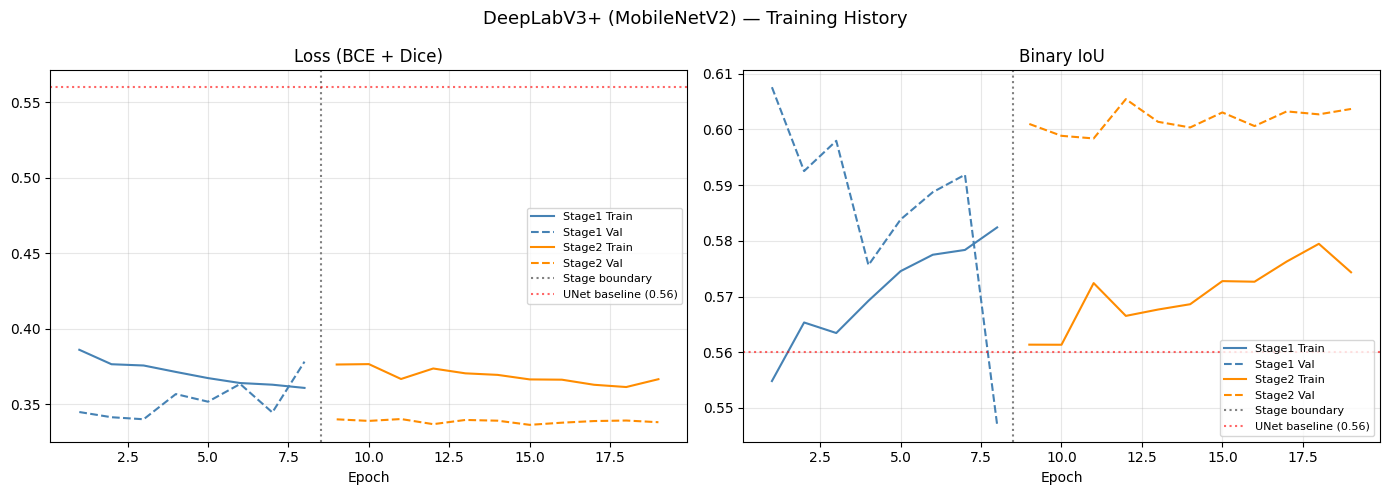

In [25]:
# Use history1_resumed since you resumed from epoch 19
# If you ran the original Cell 5 fully, replace history1_resumed with history1

h1 = history1_resumed   # ← change to history1 if you ran Cell 5 fully
h2 = history2

s1_n = len(h1.history['loss'])
s2_n = len(h2.history['loss'])
x1   = range(1, s1_n + 1)
x2   = range(s1_n + 1, s1_n + s2_n + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepLabV3+ (MobileNetV2) — Training History', fontsize=13)

for ax, metric, title in zip(
    axes,
    ['loss', 'binary_iou'],
    ['Loss (BCE + Dice)', 'Binary IoU']
):
    ax.plot(x1, h1.history[metric],          color='steelblue',  label='Stage1 Train')
    ax.plot(x1, h1.history[f'val_{metric}'], color='steelblue',  label='Stage1 Val',  linestyle='--')
    ax.plot(x2, h2.history[metric],          color='darkorange', label='Stage2 Train')
    ax.plot(x2, h2.history[f'val_{metric}'], color='darkorange', label='Stage2 Val',  linestyle='--')
    ax.axvline(x=s1_n + 0.5, color='gray', linestyle=':', label='Stage boundary')
    ax.axhline(y=0.56, color='red', linestyle=':', alpha=0.6, label='UNet baseline (0.56)')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'deeplab_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

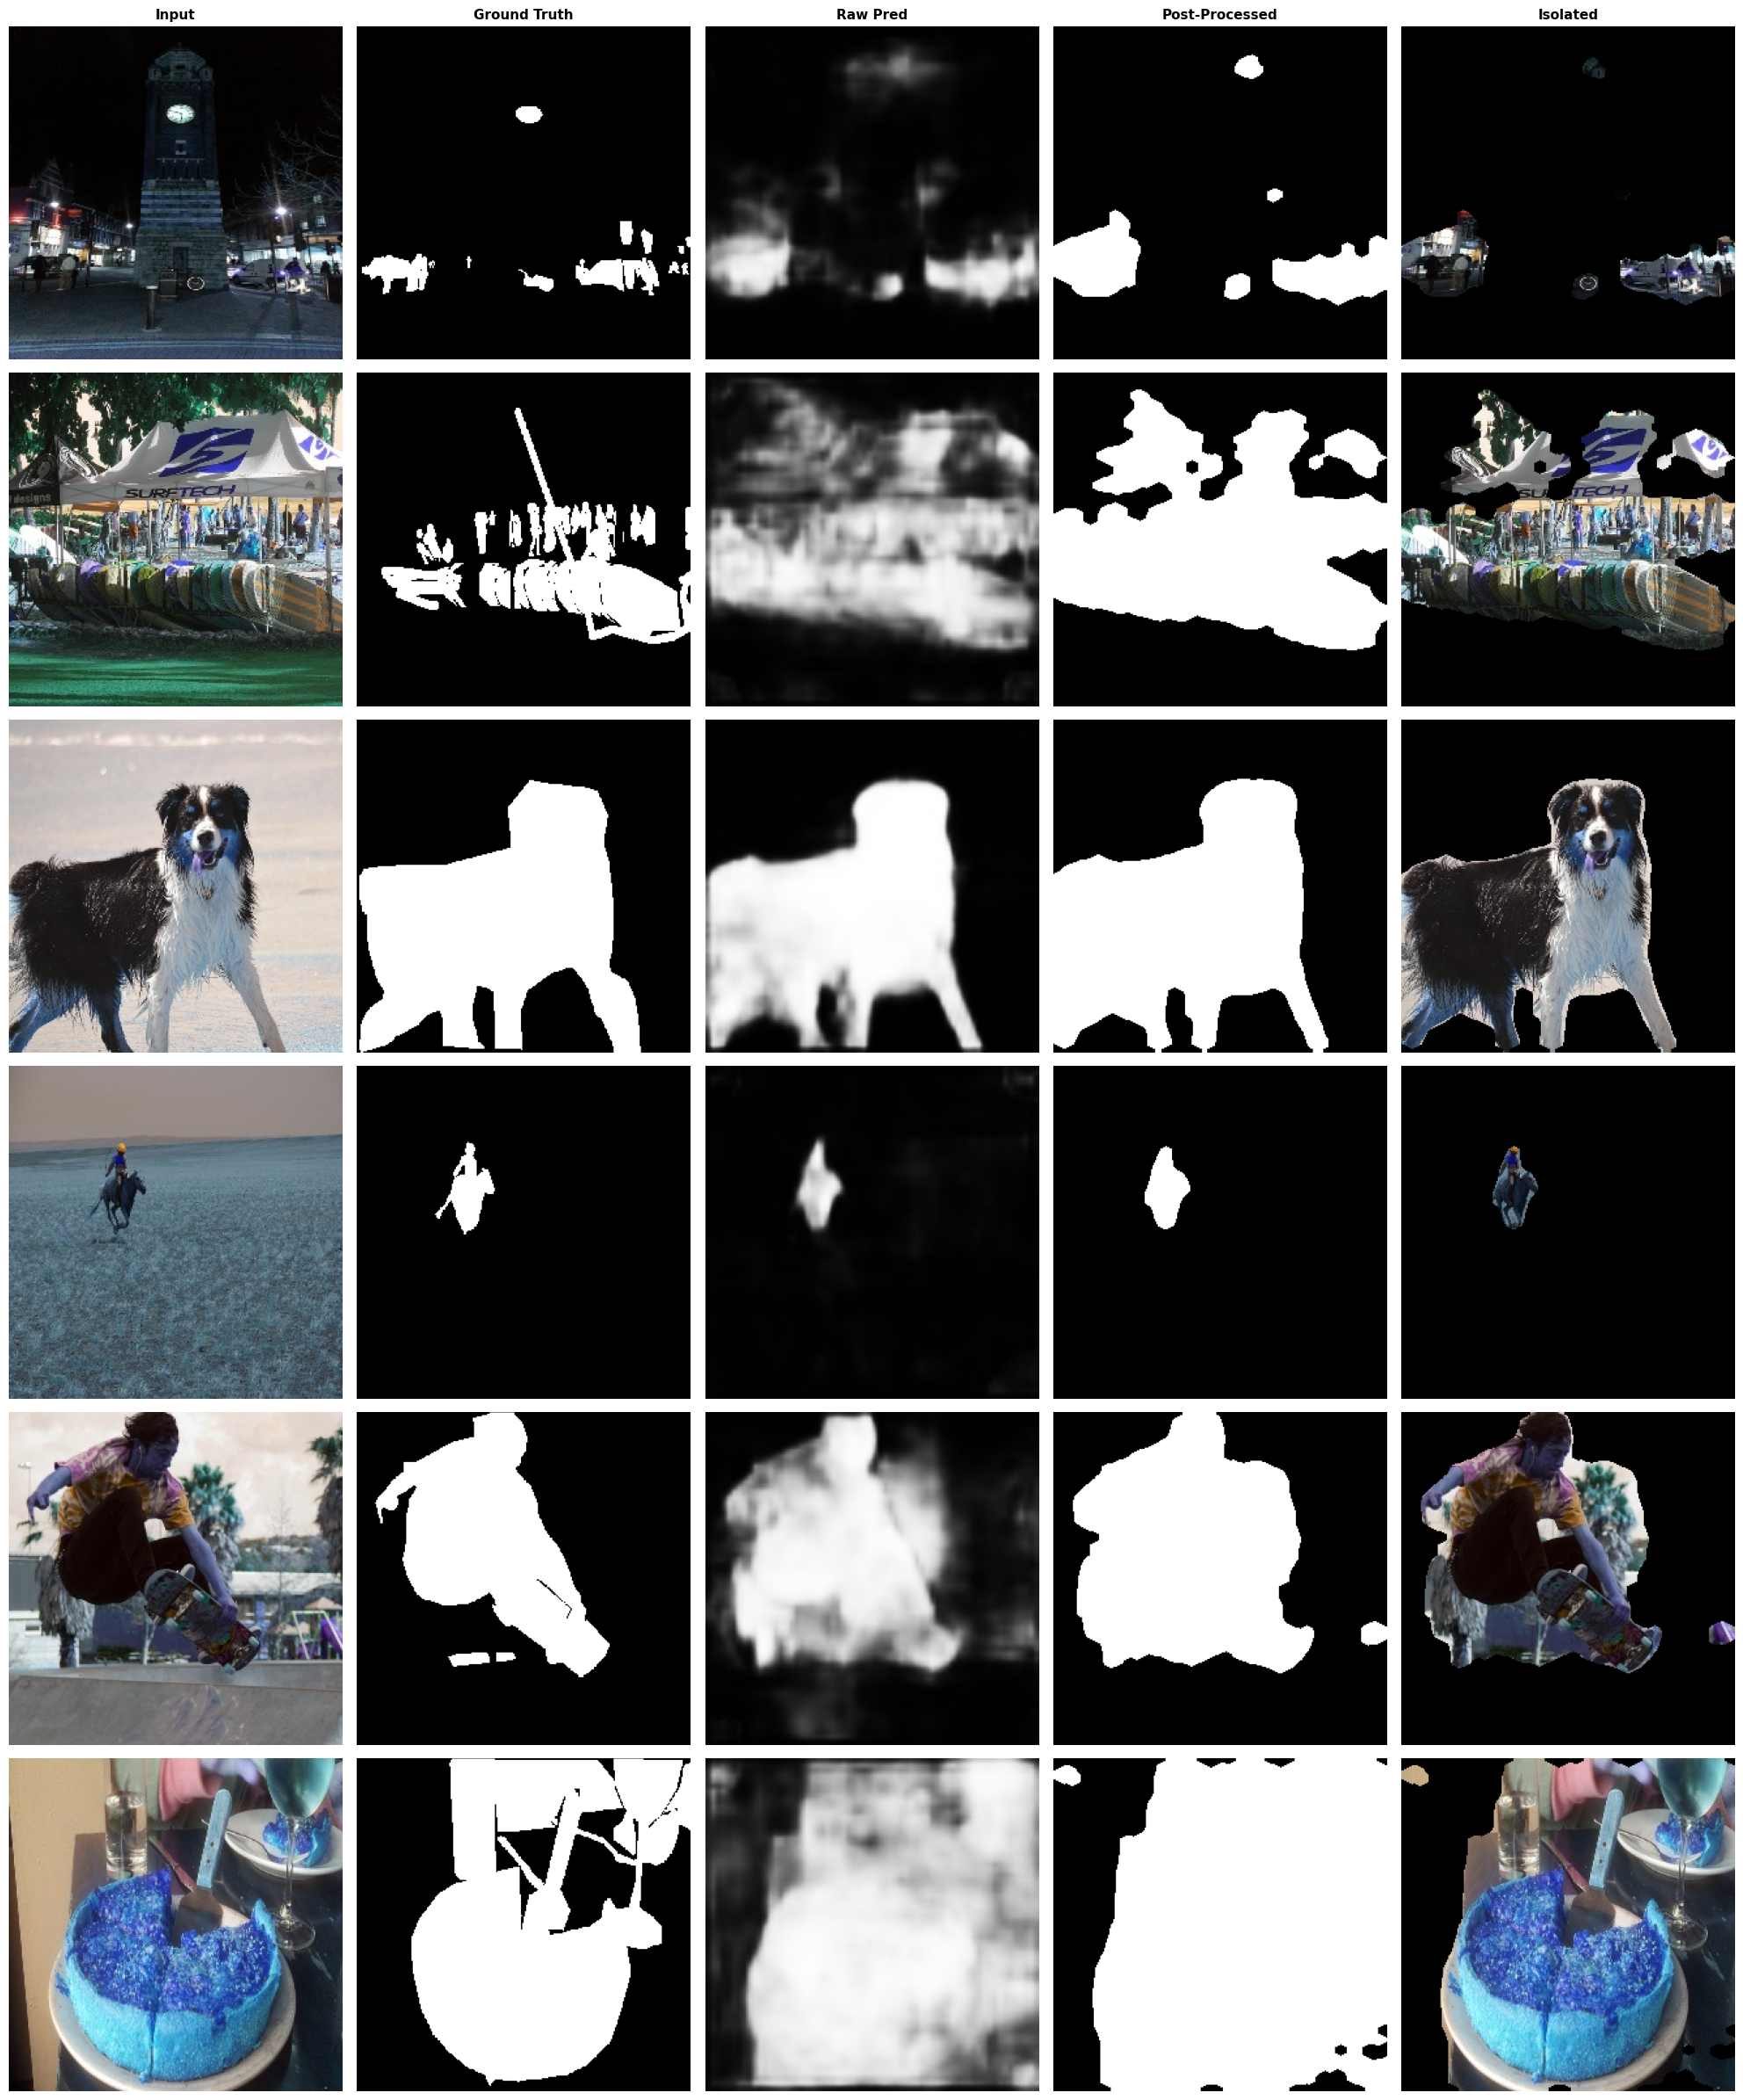

In [26]:
def post_process_mask(pred, threshold=0.3):
    binary = (pred > threshold).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    return binary

model.load_weights(os.path.join(MODEL_DIR, 'deeplab_best_stage2.keras'))

ids     = [f.replace('_normalized.jpg', '') for f in os.listdir(VAL_DIR)
           if f.endswith('_normalized.jpg')]
sampled = np.random.choice(ids, size=min(6, len(ids)), replace=False)

fig, axes = plt.subplots(6, 5, figsize=(20, 24))
for ax, col in zip(axes[0], ['Input', 'Ground Truth', 'Raw Pred', 'Post-Processed', 'Isolated']):
    ax.set_title(col, fontsize=11, fontweight='bold')

for row, img_id in enumerate(sampled):
    img  = cv2.cvtColor(
        cv2.imread(os.path.join(VAL_DIR, f'{img_id}_normalized.jpg')),
        cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
    mask = cv2.imread(os.path.join(VAL_DIR, f'{img_id}_mask.png'), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, IMG_SIZE).astype(np.float32) / 255.0

    pred     = model.predict(np.expand_dims(img, 0), verbose=0)[0, :, :, 0]
    post     = post_process_mask(pred)
    isolated = img.copy()
    isolated[post == 0] = 0

    axes[row, 0].imshow(img)
    axes[row, 1].imshow(mask,     cmap='gray')
    axes[row, 2].imshow(pred,     cmap='gray', vmin=0, vmax=1)
    axes[row, 3].imshow(post,     cmap='gray')
    axes[row, 4].imshow(isolated)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'deeplab_val_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [27]:
def compute_metrics(y_true, y_pred, threshold=0.3):
    pred = (y_pred  > threshold).astype(np.float32)
    true = (y_true  > threshold).astype(np.float32)
    intersection = np.sum(pred * true)
    union         = np.sum(pred) + np.sum(true) - intersection
    iou  = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (np.sum(pred) + np.sum(true) + 1e-6)
    acc  = np.mean(pred == true)
    return iou, dice, acc

test_ids = [f.replace('_normalized.jpg', '')
            for f in os.listdir(TEST_DIR) if f.endswith('_normalized.jpg')]

ious, dices, accs = [], [], []
for img_id in test_ids:
    img  = cv2.cvtColor(
        cv2.imread(os.path.join(TEST_DIR, f'{img_id}_normalized.jpg')),
        cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
    mask = cv2.imread(os.path.join(TEST_DIR, f'{img_id}_mask.png'), cv2.IMREAD_GRAYSCALE)
    if mask is None: continue
    mask = cv2.resize(mask, IMG_SIZE).astype(np.float32) / 255.0
    pred = model.predict(np.expand_dims(img, 0), verbose=0)[0, :, :, 0]
    iou, dice, acc = compute_metrics(mask, pred)
    ious.append(iou); dices.append(dice); accs.append(acc)

print('=' * 52)
print('TEST RESULTS — DeepLabV3+ (MobileNetV2 backbone)')
print('=' * 52)
print(f'Mean IoU        : {np.mean(ious):.4f}  (UNet baseline: 0.56)')
print(f'Mean Dice       : {np.mean(dices):.4f}')
print(f'Pixel Accuracy  : {np.mean(accs):.4f}')
print('=' * 52)

TEST RESULTS — DeepLabV3+ (MobileNetV2 backbone)
Mean IoU        : 0.5454  (UNet baseline: 0.56)
Mean Dice       : 0.6672
Pixel Accuracy  : 0.8332
